Loading...
✓ Loaded dataset with 45 instances
✓ Loaded fleet data with 100 vehicles
✓ Computed normalization constants

DDQN Agent Initialization
Using device: cuda
GPU: NVIDIA RTX A5000
GPU Memory: 25.76 GB
CUDA Version: 12.1

Initializing DDQN Architecture on device: cuda
Using default vehicle input dimension: 7 (x, y, battery, max_battery, time, dist_next, remaining_dist)
✓ All networks successfully moved to cuda
Total trainable parameters: 114,023
All networks loaded from prefix: models/model_final

Instance: RC2_10_9.txt | Vehicle: V15
Route length: 8 | Max battery: 150

Charging #1: S89 | Portion: 90% | Battery: 33.0 -> 52.6
Charging #2: S407 | Portion: 90% | Battery: 52.6 -> 48.1
Charging #3: S286 | Portion: 90% | Battery: 48.1 -> 10.2

Total charging stops: 3

Auto-zoom bounds: X=[222.8, 458.1], Y=[191.3, 335.6]
Saved map to: output_images\route_map_RC2_10_9.txt_V15.png


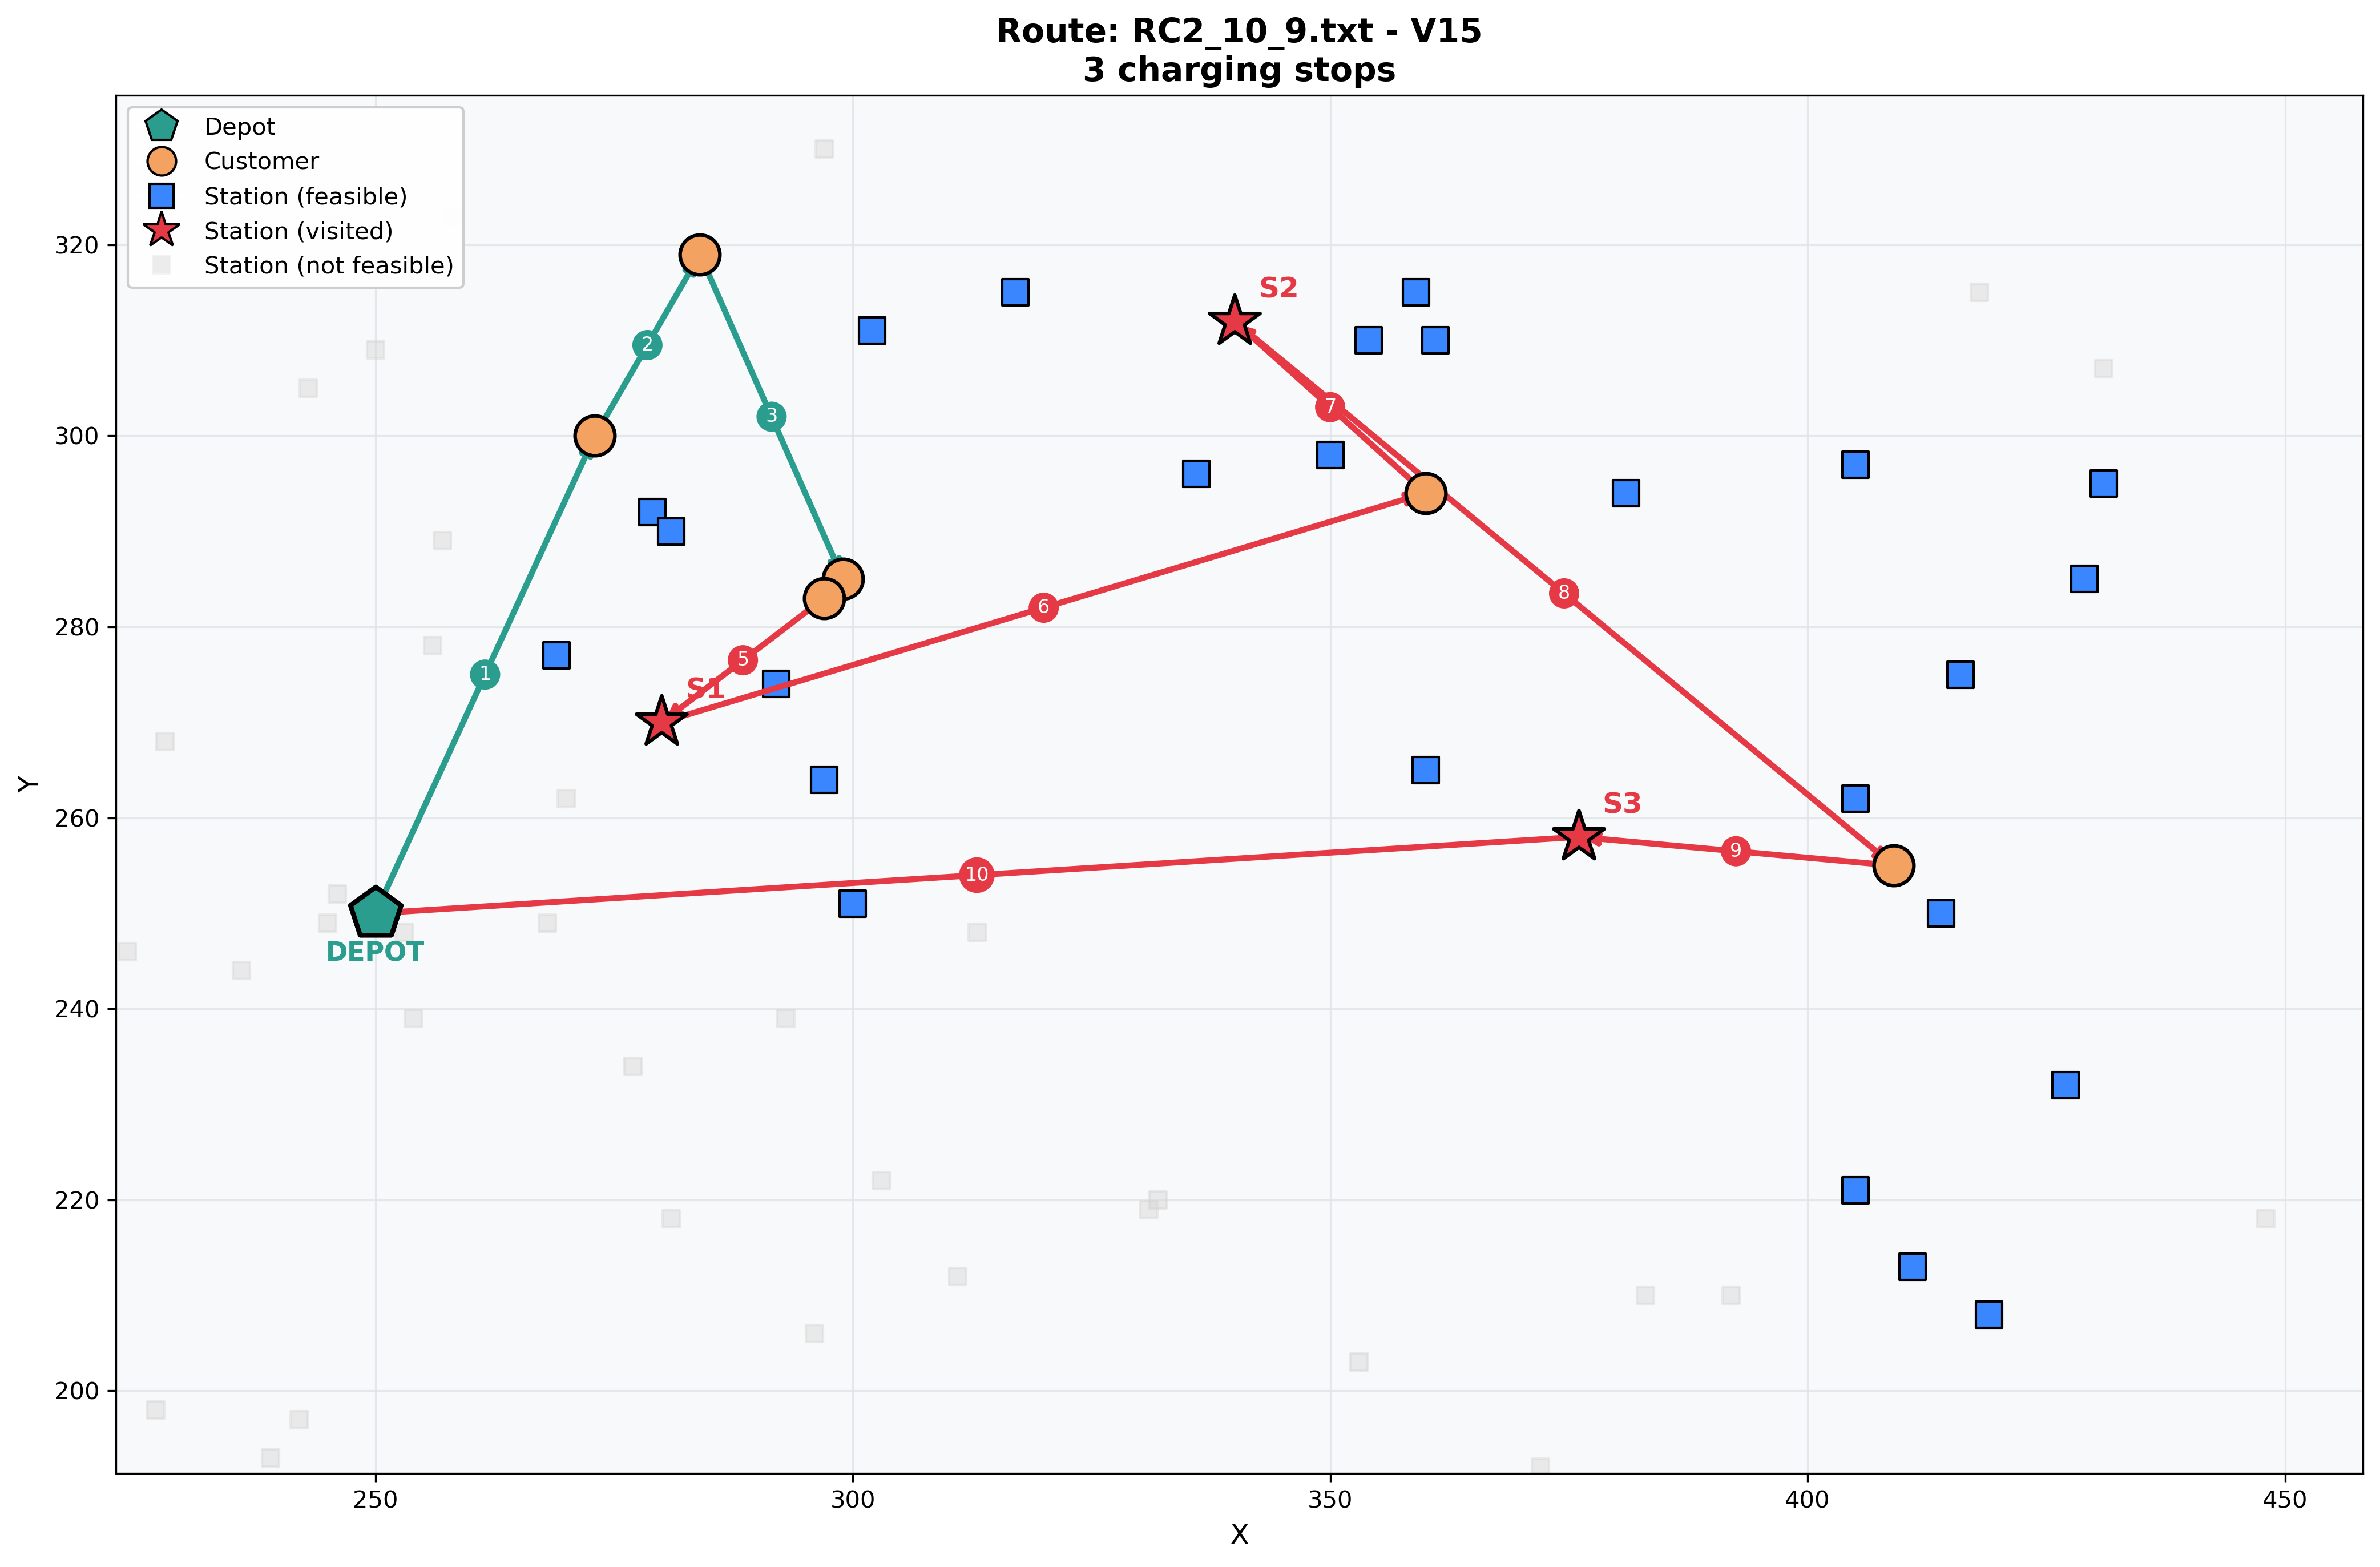

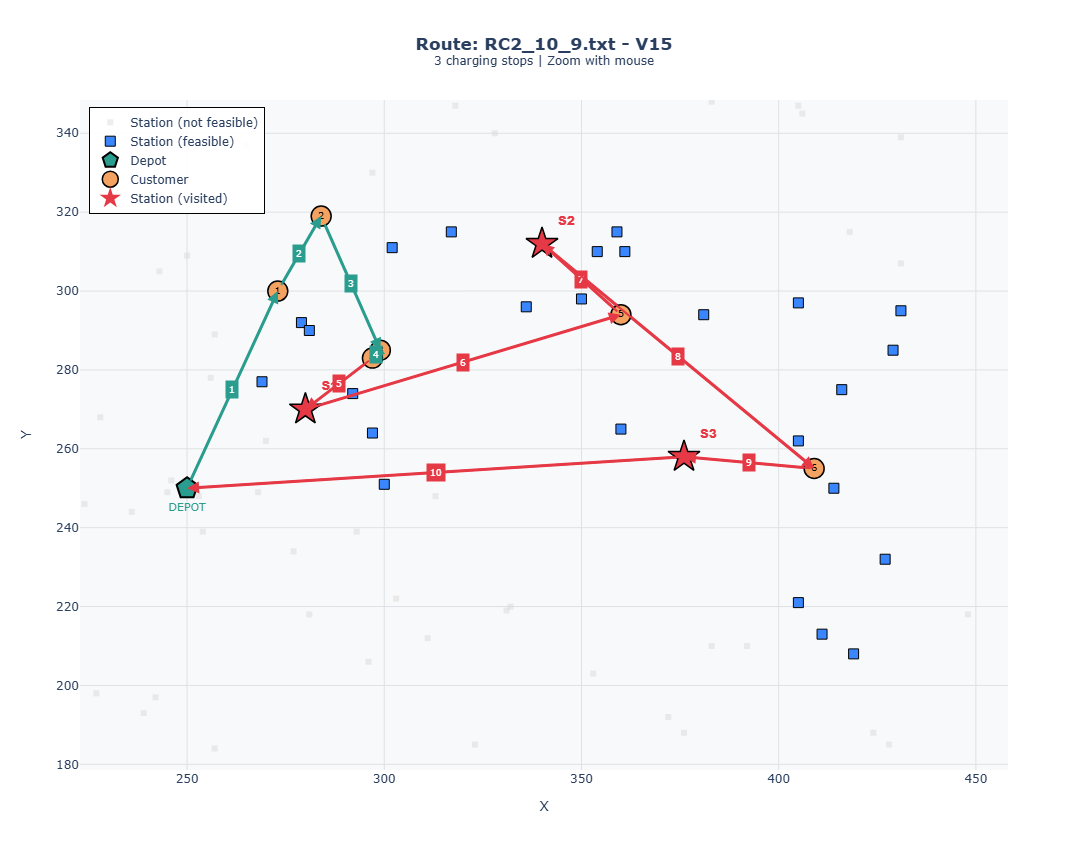

Saved battery evolution to: output_images\battery_evolution_RC2_10_9.txt_V15.png


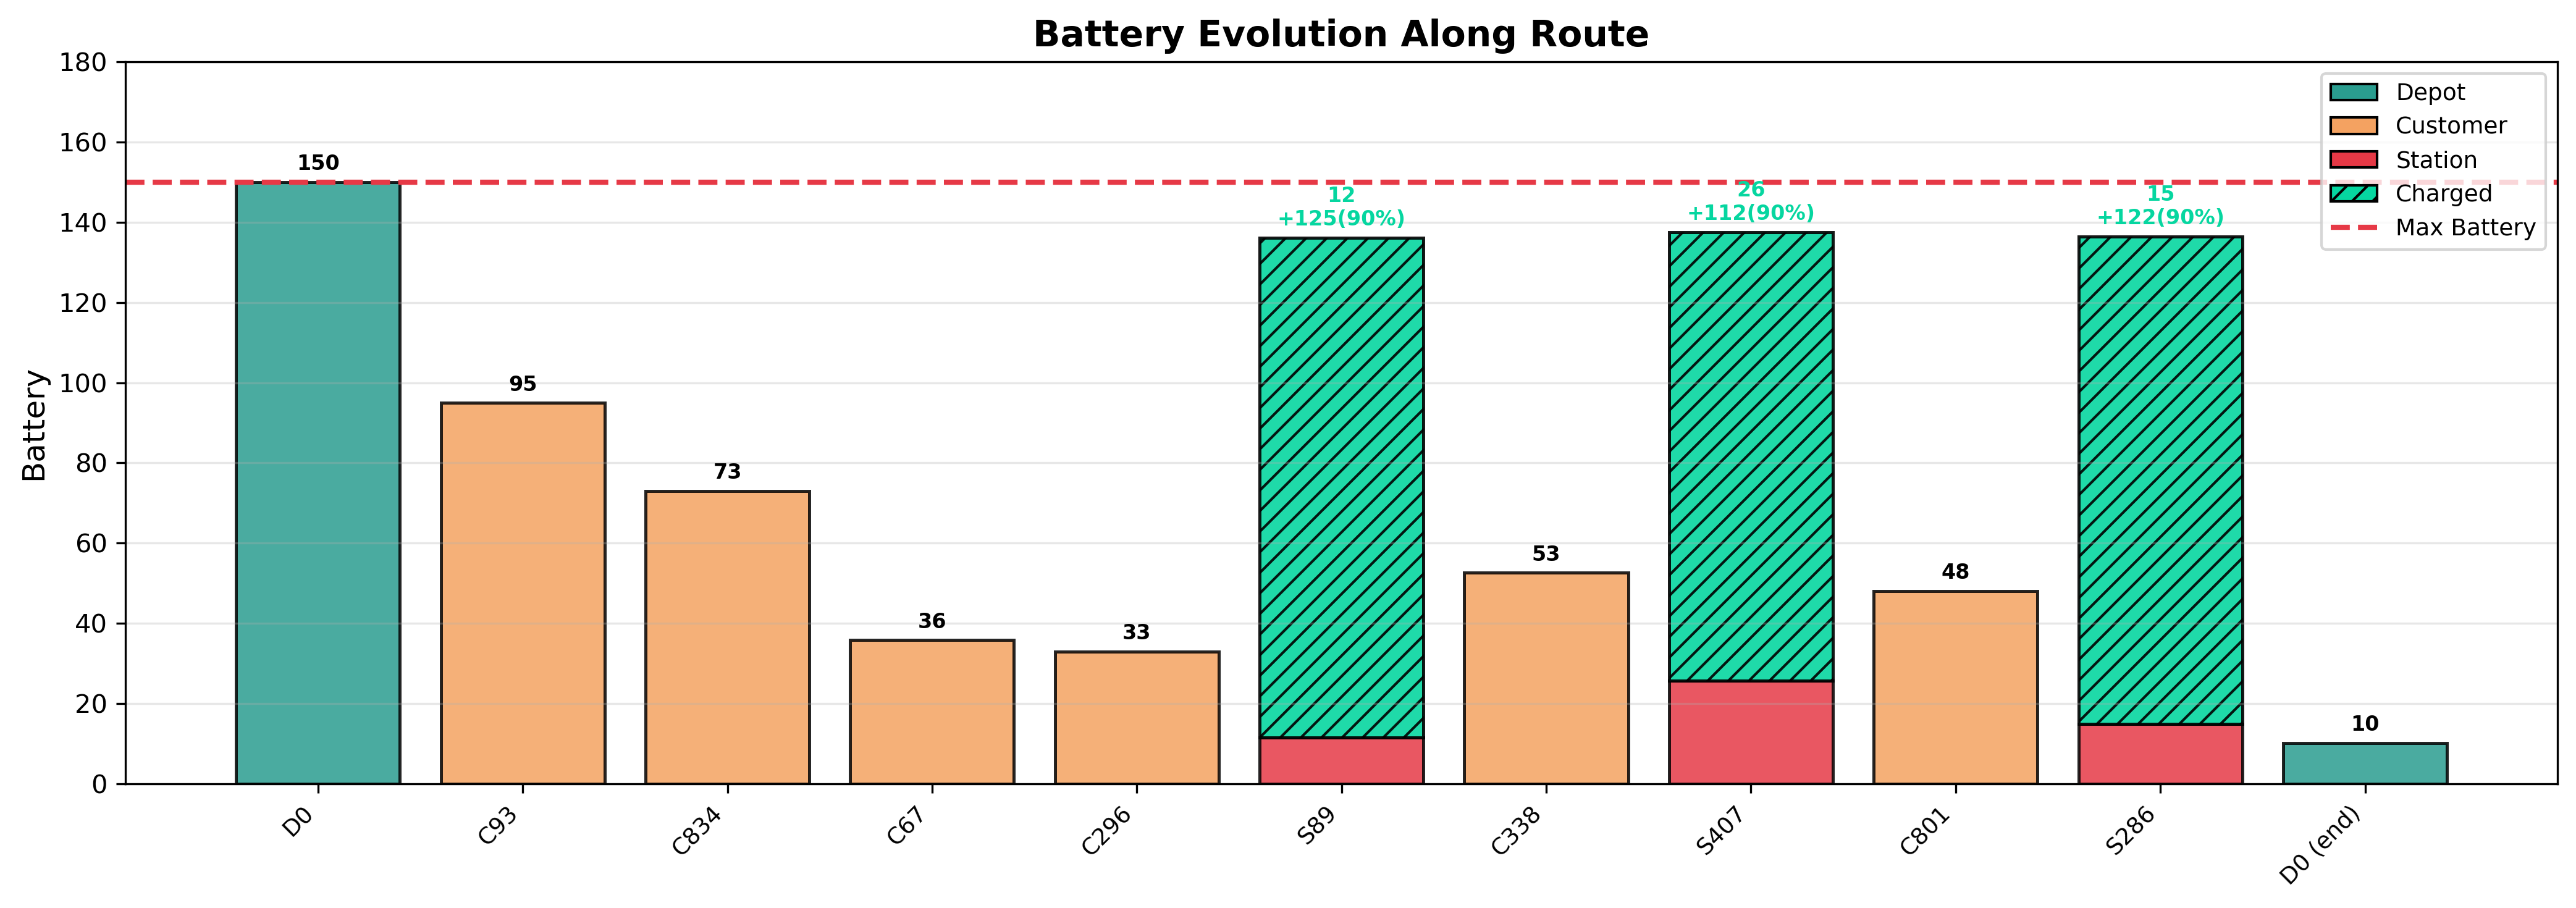

Saved charging efficiency to: output_images\charging_efficiency_RC2_10_9.txt_V15.png


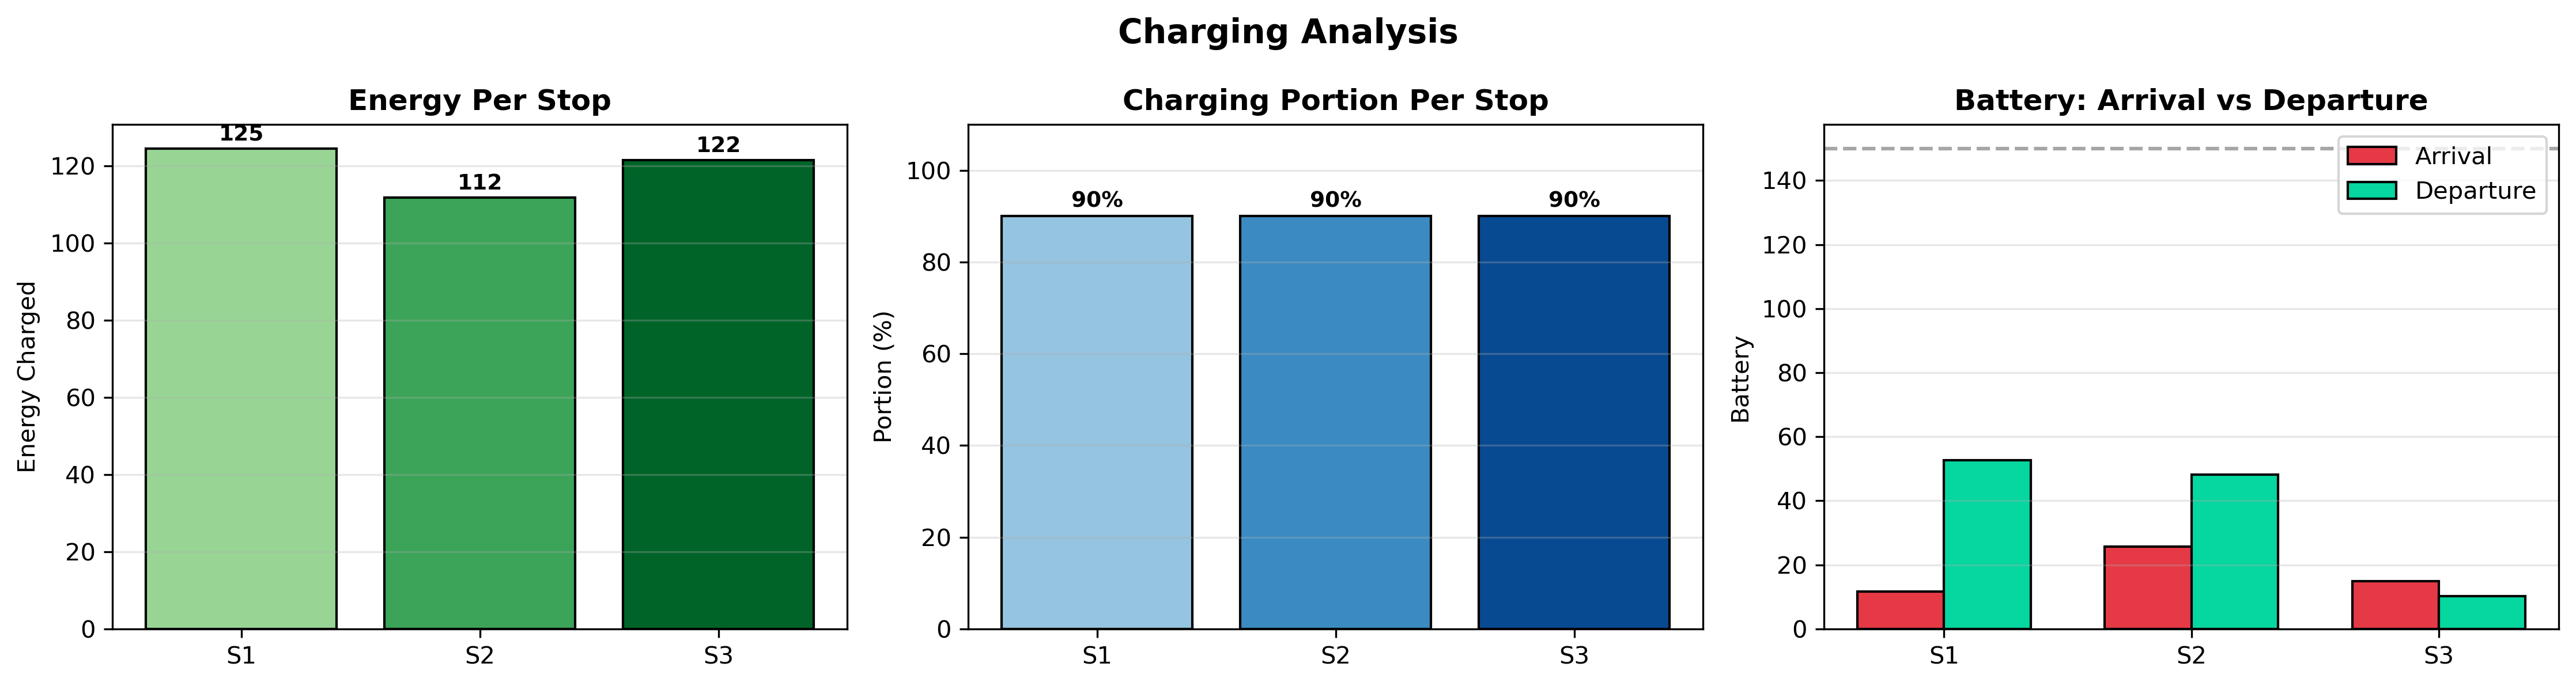

Saved decision #1 to: output_images\decision_1_RC2_10_9.txt_V15.png


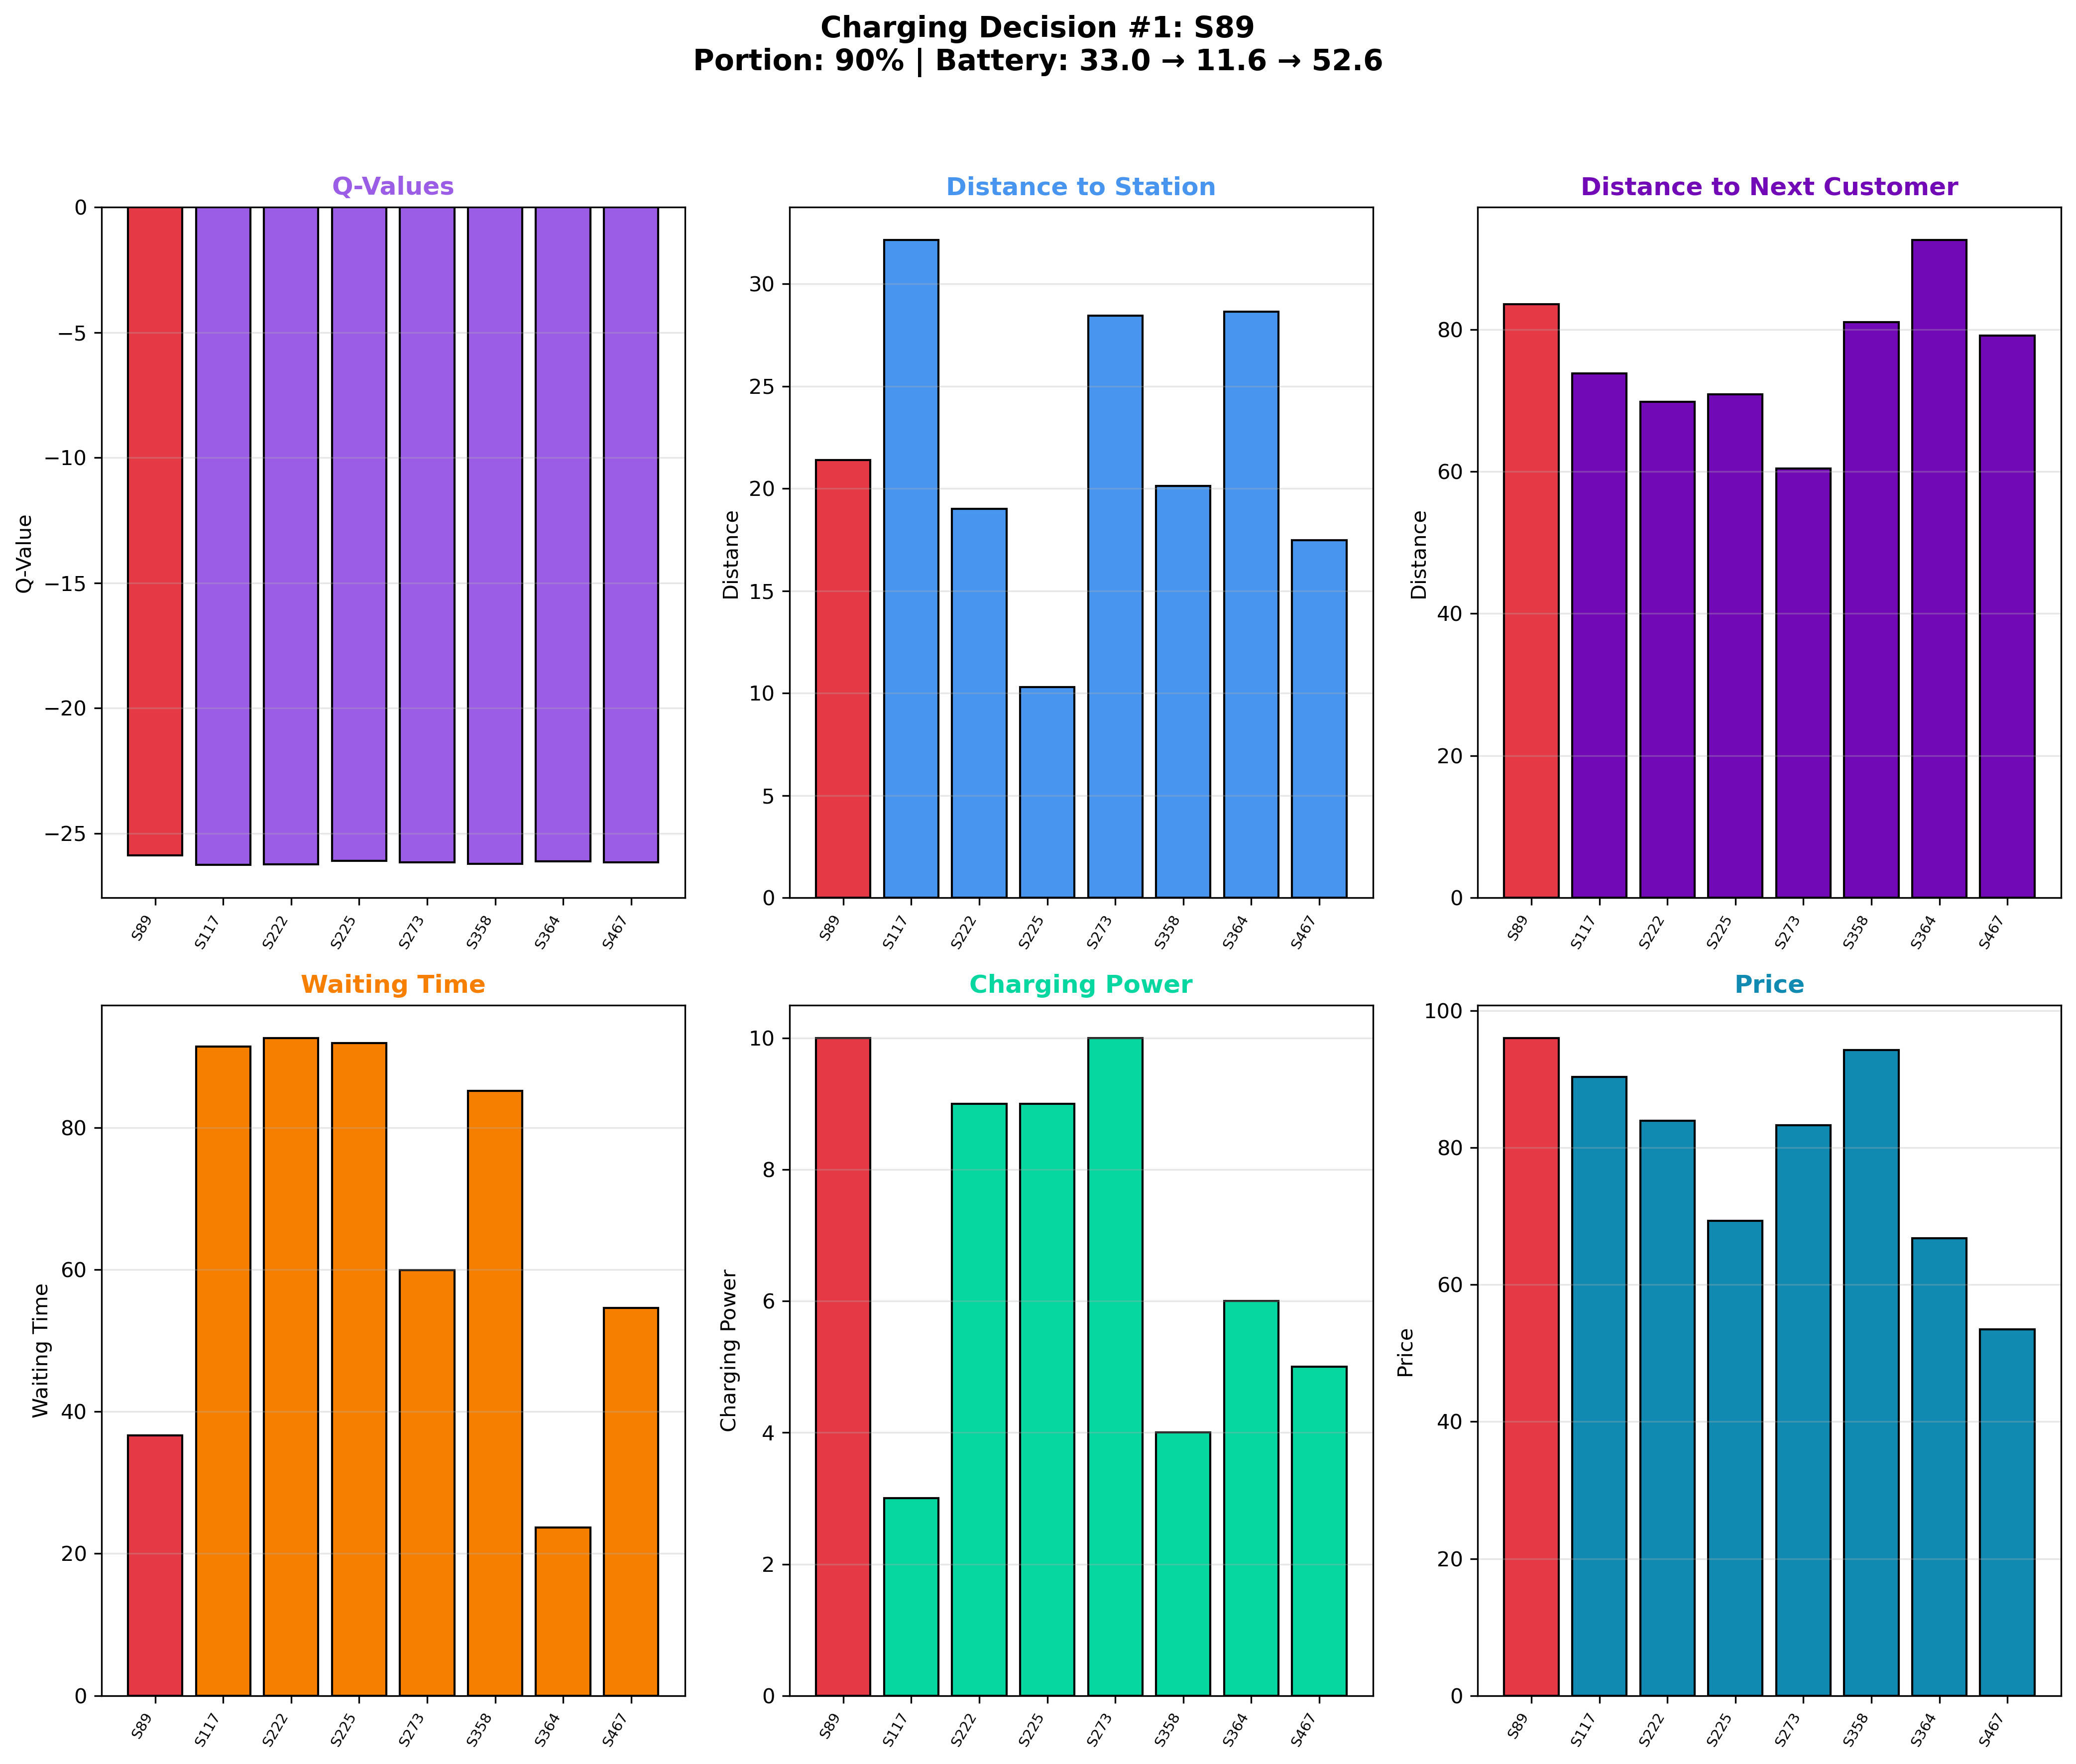

Saved decision #2 to: output_images\decision_2_RC2_10_9.txt_V15.png


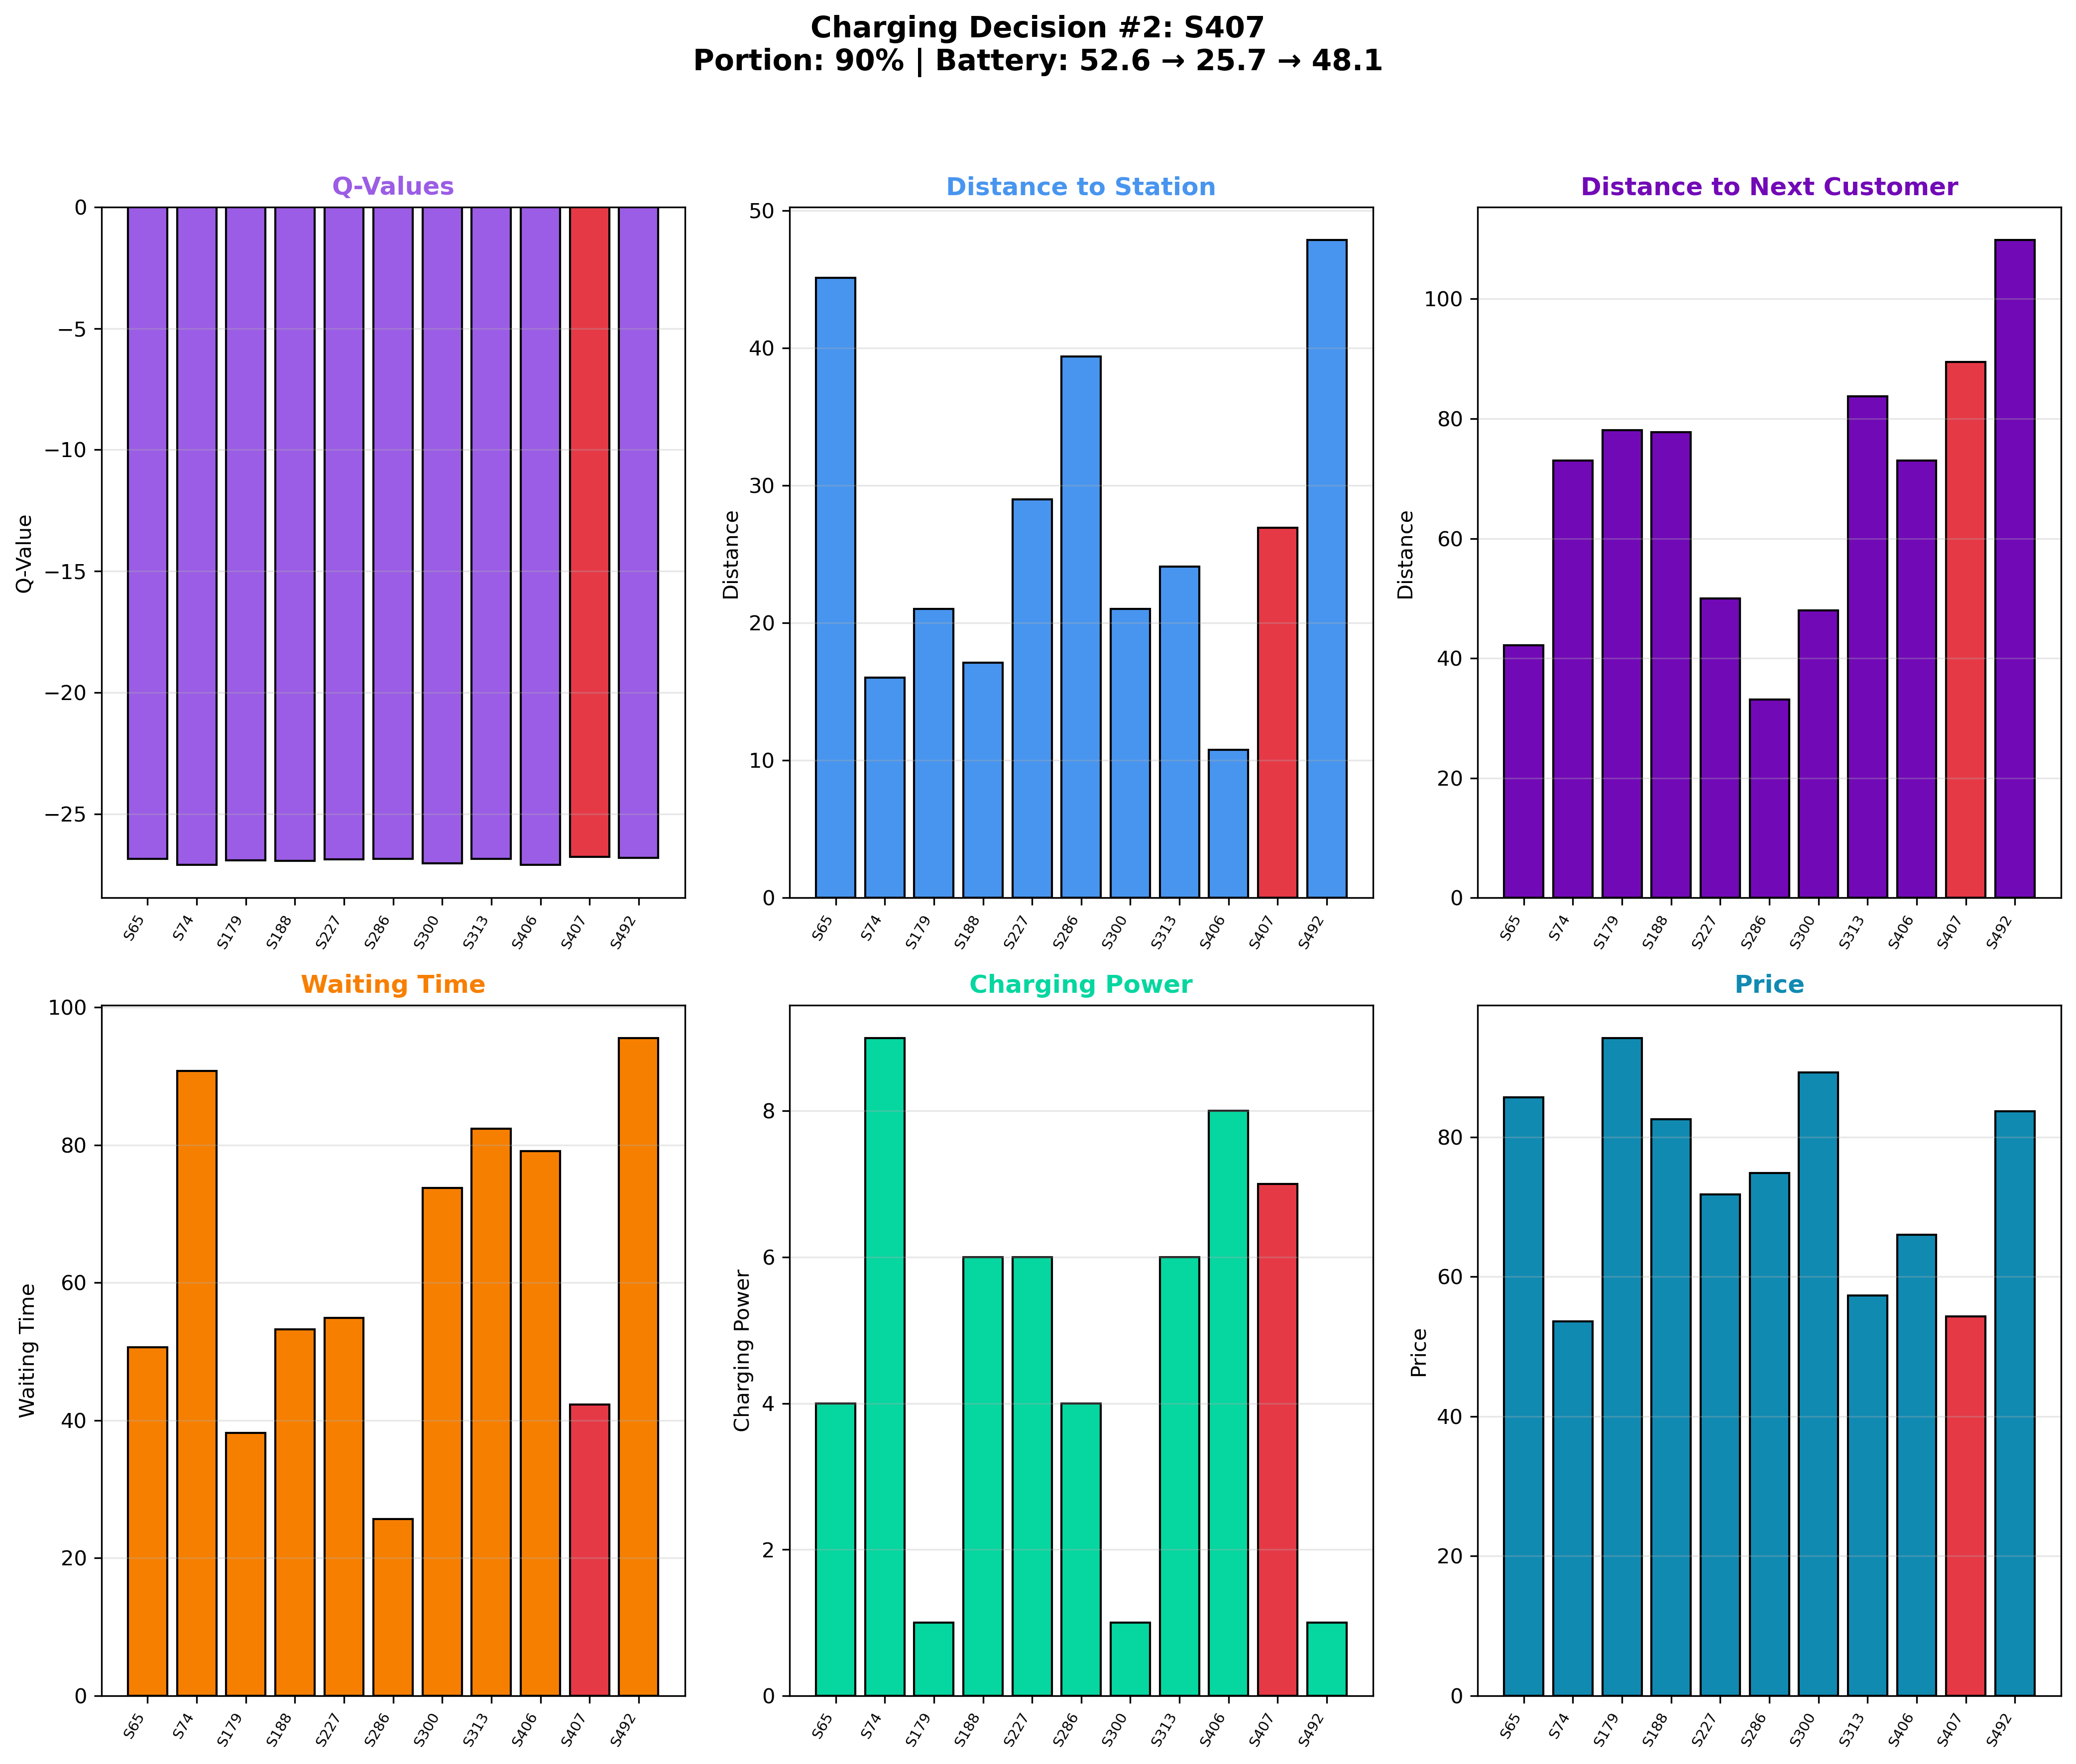

Saved decision #3 to: output_images\decision_3_RC2_10_9.txt_V15.png


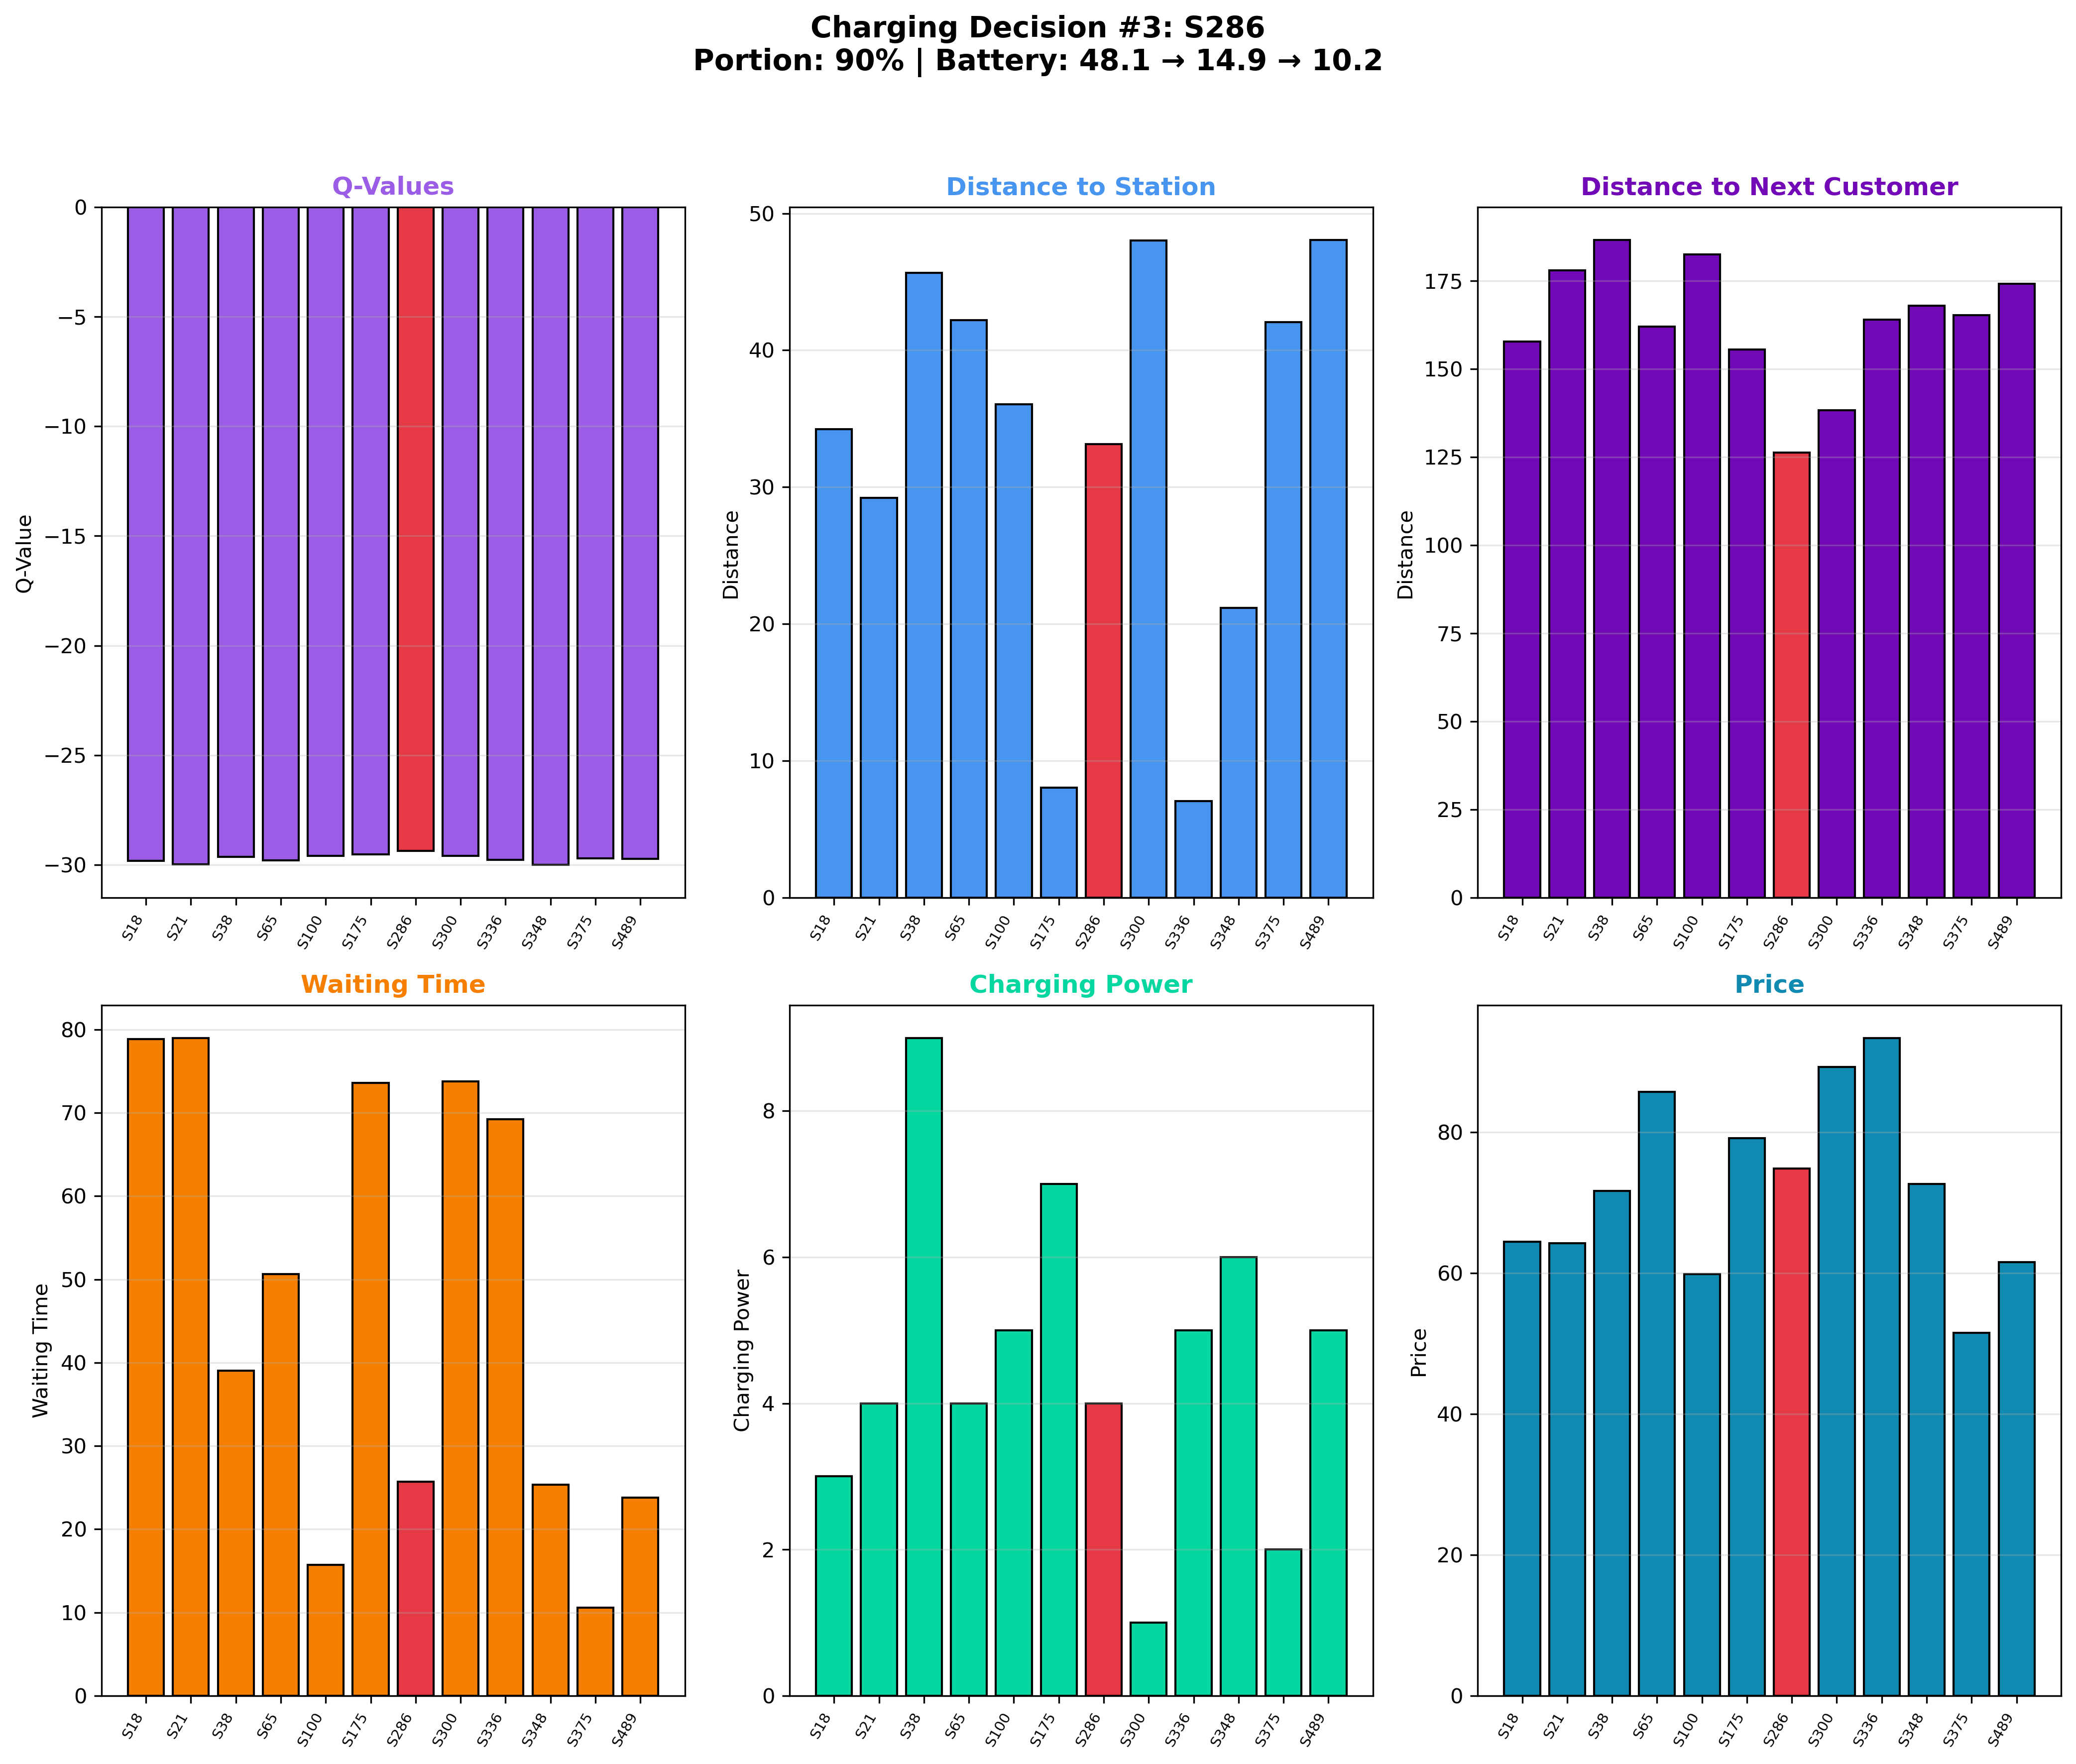


SUMMARY
Total charging stops: 3
Total energy charged: 357.9
Final battery: 10.2

All images saved to: output_images/


In [23]:
# Test model - Full route with all charging decisions
# FIXED VERSION: Auto-zoom to relevant area + High-resolution image saving (NO kaleido)

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torch

# Uncomment these imports when using with your project
# from data_manager import DataManager
# from environment import Environment
# from ddqn_agent import DDQNAgent
# from helper_functions import HelperFunctions


def calculate_bounds(points, padding_percent=0.15):
    """
    Calculate bounding box for a set of points with padding.
    
    Args:
        points: List of (x, y) tuples
        padding_percent: Percentage of range to add as padding (default 15%)
    
    Returns:
        (x_min, x_max, y_min, y_max) with padding applied
    """
    if not points:
        return None
    
    x_coords = [p[0] for p in points]
    y_coords = [p[1] for p in points]
    
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)
    
    # Calculate padding
    x_range = x_max - x_min
    y_range = y_max - y_min
    
    # Ensure minimum range to avoid too tight zoom
    x_range = max(x_range, 50)
    y_range = max(y_range, 50)
    
    x_padding = x_range * padding_percent
    y_padding = y_range * padding_percent
    
    return (
        x_min - x_padding,
        x_max + x_padding,
        y_min - y_padding,
        y_max + y_padding
    )


def get_relevant_points(customers, stations, route, charging_decisions, depot, all_feasible_ids):
    """
    Collect all points that should be visible in the zoomed view.
    Includes: depot, customers on route, visited stations, and feasible stations.
    """
    points = []
    
    # Add depot
    if depot:
        points.append((depot['x'], depot['y']))
    
    # Add all customers on the route
    for node_id in route:
        if node_id in customers and node_id != 'D0':
            c = customers[node_id]
            points.append((c['x'], c['y']))
    
    # Add visited stations
    for decision in charging_decisions:
        station_id = decision['station_id']
        if station_id in stations:
            s = stations[station_id]
            points.append((s['x'], s['y']))
    
    # Add feasible stations (they're relevant context)
    for station_id in all_feasible_ids:
        if station_id in stations:
            s = stations[station_id]
            points.append((s['x'], s['y']))
    
    return points


def plot_route_map_matplotlib(customers, stations, route, charging_decisions, depot, 
                               all_feasible_ids, visited_station_ids, actual_path,
                               bounds, instance_id, vehicle_id, save_path=None, dpi=300):
    """
    Plot the route map using matplotlib (for saving high-res images).
    """
    x_min, x_max, y_min, y_max = bounds
    
    fig, ax = plt.subplots(figsize=(14, 11), dpi=dpi)
    ax.set_facecolor('#f8f9fa')
    ax.grid(True, color='#dee2e6', alpha=0.7, zorder=0)
    
    # Only plot stations within the zoom bounds (with margin)
    margin = 20
    for sid, s in stations.items():
        if not (x_min - margin <= s['x'] <= x_max + margin and y_min - margin <= s['y'] <= y_max + margin):
            continue  # Skip stations outside view
            
        if sid in visited_station_ids:
            ax.scatter(s['x'], s['y'], s=500, c='#e63946', marker='*', zorder=10, edgecolors='black', linewidths=1.5)
        elif sid in all_feasible_ids:
            ax.scatter(s['x'], s['y'], s=120, c='#3a86ff', marker='s', zorder=4, edgecolors='black', linewidths=1)
        else:
            ax.scatter(s['x'], s['y'], s=50, c='#d3d3d3', marker='s', zorder=2, alpha=0.4)
    
    # Draw path connections
    for i in range(len(actual_path) - 1):
        p1, p2 = actual_path[i], actual_path[i + 1]
        color = '#e63946' if p2['type'] == 'station' or p1['type'] == 'station' else '#2a9d8f'
        ax.annotate('', xy=(p2['x'], p2['y']), xytext=(p1['x'], p1['y']), 
                   arrowprops=dict(arrowstyle='->', color=color, lw=2.5), zorder=5)
        mid_x, mid_y = (p1['x'] + p2['x']) / 2, (p1['y'] + p2['y']) / 2
        ax.text(mid_x, mid_y, str(i + 1), fontsize=8, color='white', ha='center', va='center', 
               bbox=dict(boxstyle='circle,pad=0.3', facecolor=color, edgecolor='none'), zorder=7)
    
    # Draw customers and depot
    for i, nid in enumerate(route):
        if nid in customers:
            c = customers[nid]
            if nid == 'D0':
                ax.scatter(c['x'], c['y'], s=500, c='#2a9d8f', marker='p', zorder=8, edgecolors='black', linewidths=2)
                ax.annotate('DEPOT', (c['x'], c['y']), xytext=(0, -20), textcoords='offset points', 
                           ha='center', fontsize=11, fontweight='bold', color='#2a9d8f')
            else:
                ax.scatter(c['x'], c['y'], s=280, c='#f4a261', marker='o', zorder=8, edgecolors='black', linewidths=1.5)
                ax.text(c['x'], c['y'], str(i), ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Label visited stations
    for i, d in enumerate(charging_decisions):
        s = stations[d['station_id']]
        ax.annotate(f"S{i+1}", (s['x'], s['y']), xytext=(10, 10), textcoords='offset points', 
                   fontsize=12, fontweight='bold', color='#e63946')
    
    # Apply zoom bounds
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', adjustable='box')
    
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_title(f'Route: {instance_id} - {vehicle_id}\n{len(charging_decisions)} charging stops', 
                fontsize=14, fontweight='bold')
    
    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], marker='p', color='w', markerfacecolor='#2a9d8f', markersize=14, 
                   markeredgecolor='black', label='Depot'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#f4a261', markersize=12, 
                   markeredgecolor='black', label='Customer'),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#3a86ff', markersize=10, 
                   markeredgecolor='black', label='Station (feasible)'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='#e63946', markersize=16, 
                   markeredgecolor='black', label='Station (visited)'),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#d3d3d3', markersize=8, 
                   alpha=0.4, label='Station (not feasible)')
    ]
    ax.legend(handles=legend_elements, loc='upper left', framealpha=0.95, fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white', edgecolor='none')
        print(f"Saved map to: {save_path}")
    
    plt.show()
    plt.close(fig)


def test_full_route(instance_id, vehicle_id,
                    model_path="models/model_final",
                    dataset_path="test_dataset.json",
                    fleet_path="fleet.json",
                    save_images=True,
                    output_dir="output_images",
                    dpi=300,
                    show_plotly=True):
    """
    Test model on a full route with all charging decisions.
    
    Args:
        instance_id: Instance identifier
        vehicle_id: Vehicle identifier
        model_path: Path to trained model
        dataset_path: Path to test dataset
        fleet_path: Path to fleet specifications
        save_images: Whether to save images as PNG files
        output_dir: Directory to save images
        dpi: Resolution for saved images (300 = high quality)
        show_plotly: Whether to show interactive Plotly map (images always saved with matplotlib)
    """
    
    # Create output directory if saving images
    if save_images:
        os.makedirs(output_dir, exist_ok=True)
    
    print("Loading...")
    dm = DataManager(dataset_path=dataset_path, fleet_path=fleet_path)
    env = Environment(dm)
    helper = HelperFunctions()
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    agent = DDQNAgent(epsilon=0.0, device=device)
    agent.load(model_path)
    agent.epsilon = 0.0
    
    # Get instance key
    inst_key = None
    for key, inst in dm.get_all_instances().items():
        if inst.get('instance_id', '').upper() == instance_id.upper():
            inst_key = key
            break
    
    if not inst_key:
        print(f"Instance '{instance_id}' not found!")
        return None, None
    
    customers = dm.get_customers(inst_key)
    stations = dm.get_stations(inst_key)
    vehicle, _ = dm.get_vehicle_data(inst_key, vehicle_id)
    route = vehicle.get('route', [])
    fleet_specs = dm.get_fleet_specs(vehicle_id)
    max_battery = fleet_specs.get('driving_range_km', 200.0)
    initial_battery = fleet_specs.get('remaining_driving_range_km', max_battery)
    depot = dm.get_depot(inst_key)
    
    print(f"\n{'='*60}")
    print(f"Instance: {instance_id} | Vehicle: {vehicle_id}")
    print(f"Route length: {len(route)} | Max battery: {max_battery}")
    print(f"{'='*60}\n")
    
    # Initialize environment
    state = env.reset(inst_key, vehicle_id)
    
    if state is None:
        print("No charging needed for this vehicle!")
        return None, None
    
    # Run through route
    charging_decisions = []
    done = False
    
    while not done:
        station_idx, portion_idx = agent.select_action(state, training=False)
        
        station_id = state['station_ids'][station_idx]
        portion = agent.charge_portions[portion_idx]
        station = stations[station_id]
        
        feasible_stations = state['station_ids']
        station_details = []
        
        next_node_id = route[env.route_index + 1] if env.route_index + 1 < len(route) else None
        next_pos = None
        if next_node_id and next_node_id in customers:
            nc = customers[next_node_id]
            next_pos = (nc['x'], nc['y'])
        
        for sid in feasible_stations:
            s = stations[sid]
            sp = (s['x'], s['y'])
            station_details.append({
                'id': sid,
                'dist_to': helper.euclidean_distance(env.current_position[0], env.current_position[1], sp[0], sp[1]),
                'dist_from': helper.euclidean_distance(sp[0], sp[1], next_pos[0], next_pos[1]) if next_pos else 0,
                'waiting_time': s.get('waiting_time', 0),
                'charging_power': s.get('charging_power', 10),
                'price': s.get('price', 1)
            })
        
        decision = {
            'step': len(charging_decisions) + 1,
            'station_id': station_id,
            'portion': portion,
            'battery_before': env.current_battery,
            'position_before': env.current_position,
            'route_index_before': env.route_index,
            'feasible_stations': feasible_stations.copy(),
            'station_details': station_details,
            'q_values': None
        }
        
        with torch.no_grad():
            sf = torch.from_numpy(state['station_features']).float().to(device).unsqueeze(0)
            am = torch.from_numpy(state['adj_matrix']).float().to(device).unsqueeze(0)
            cf = torch.from_numpy(state['customer_features']).float().to(device).unsqueeze(0)
            vf = torch.from_numpy(state['vehicle_features']).float().to(device).unsqueeze(0)
            q_vals = agent.networks.get_station_q_values(sf, am, cf, vf, use_target=False, training=False)
            decision['q_values'] = q_vals.cpu().numpy().flatten()[:len(feasible_stations)]
        
        dist_to_station = helper.euclidean_distance(env.current_position[0], env.current_position[1], station['x'], station['y'])
        battery_at_station = env.current_battery - dist_to_station
        energy_charged = portion * (max_battery - battery_at_station)
        
        next_state, _, done = env.step(station_id, portion)
        
        decision['battery_after'] = env.current_battery
        decision['battery_at_station'] = battery_at_station
        decision['energy_charged'] = energy_charged
        charging_decisions.append(decision)
        
        print(f"Charging #{decision['step']}: {station_id} | Portion: {portion*100:.0f}% | Battery: {decision['battery_before']:.1f} -> {decision['battery_after']:.1f}")
        
        state = next_state
    
    print(f"\n{'='*60}")
    print(f"Total charging stops: {len(charging_decisions)}")
    print(f"{'='*60}\n")
    
    # Reconstruct full battery history (all customers)
    sim_battery = initial_battery
    sim_pos = (depot['x'], depot['y']) if depot else (0, 0)
    charging_idx = 0
    
    full_battery_history = [{'node': 'D0', 'type': 'depot', 'battery': sim_battery, 'charged': 0}]
    
    for i in range(1, len(route)):
        node_id = route[i]
        if node_id not in customers:
            continue
        
        # Skip if it's the last D0 (return to depot)
        if node_id == 'D0' and i == len(route) - 1:
            continue
        
        node = customers[node_id]
        node_pos = (node['x'], node['y'])
        
        while charging_idx < len(charging_decisions):
            d = charging_decisions[charging_idx]
            if d['route_index_before'] < i:
                s = stations[d['station_id']]
                dist_to_station = helper.euclidean_distance(sim_pos[0], sim_pos[1], s['x'], s['y'])
                sim_battery -= dist_to_station
                full_battery_history.append({'node': d['station_id'], 'type': 'station', 'battery': sim_battery, 'charged': d['energy_charged'], 'portion': d['portion']})
                sim_battery += d['energy_charged']
                sim_pos = (s['x'], s['y'])
                charging_idx += 1
            else:
                break
        
        dist = helper.euclidean_distance(sim_pos[0], sim_pos[1], node_pos[0], node_pos[1])
        sim_battery -= dist
        full_battery_history.append({'node': node_id, 'type': 'customer', 'battery': sim_battery, 'charged': 0})
        sim_pos = node_pos
    
    # Handle any remaining charging decisions before final depot
    while charging_idx < len(charging_decisions):
        d = charging_decisions[charging_idx]
        s = stations[d['station_id']]
        dist_to_station = helper.euclidean_distance(sim_pos[0], sim_pos[1], s['x'], s['y'])
        sim_battery -= dist_to_station
        full_battery_history.append({'node': d['station_id'], 'type': 'station', 'battery': sim_battery, 'charged': d['energy_charged'], 'portion': d['portion']})
        sim_battery += d['energy_charged']
        sim_pos = (s['x'], s['y'])
        charging_idx += 1
    
    # Final return to depot
    if depot:
        dist = helper.euclidean_distance(sim_pos[0], sim_pos[1], depot['x'], depot['y'])
        sim_battery -= dist
        full_battery_history.append({'node': 'D0 (end)', 'type': 'depot', 'battery': sim_battery, 'charged': 0})
    
    # Collect feasible IDs
    all_feasible_ids = set()
    for d in charging_decisions:
        all_feasible_ids.update(d['feasible_stations'])
    
    visited_station_ids = [d['station_id'] for d in charging_decisions]
    
    # Build actual path with stations properly inserted
    actual_path = []
    charging_idx = 0
    
    for i, node_id in enumerate(route):
        if node_id in customers:
            c = customers[node_id]
            actual_path.append({'id': node_id, 'x': c['x'], 'y': c['y'], 'type': 'depot' if node_id == 'D0' else 'customer'})
        
        # Insert charging station after this node if needed
        while charging_idx < len(charging_decisions) and charging_decisions[charging_idx]['route_index_before'] == i:
            s = stations[charging_decisions[charging_idx]['station_id']]
            actual_path.append({'id': charging_decisions[charging_idx]['station_id'], 'x': s['x'], 'y': s['y'], 'type': 'station', 'step': charging_idx + 1})
            charging_idx += 1
    
    # ========== CALCULATE BOUNDS FOR ZOOMING ==========
    relevant_points = get_relevant_points(customers, stations, route, charging_decisions, depot, all_feasible_ids)
    bounds = calculate_bounds(relevant_points, padding_percent=0.15)
    x_min, x_max, y_min, y_max = bounds
    
    print(f"Auto-zoom bounds: X=[{x_min:.1f}, {x_max:.1f}], Y=[{y_min:.1f}, {y_max:.1f}]")
    
    # ========== PLOT MAP (Plotly for interactive, Matplotlib for saving) ==========
    
    # Save high-resolution image with matplotlib
    if save_images:
        map_path = os.path.join(output_dir, f"route_map_{instance_id}_{vehicle_id}.png")
        plot_route_map_matplotlib(
            customers, stations, route, charging_decisions, depot,
            all_feasible_ids, visited_station_ids, actual_path,
            bounds, instance_id, vehicle_id, save_path=map_path, dpi=dpi
        )
    
    # Show interactive Plotly map (optional)
    if show_plotly:
        try:
            import plotly.graph_objects as go
            fig = go.Figure()
            
            # Filter stations to only show those within or near the bounds (with extra margin)
            margin = 20
            
            # Non-feasible stations (only show those in view)
            nf = [(sid, s) for sid, s in stations.items() 
                  if sid not in all_feasible_ids and sid not in visited_station_ids
                  and x_min - margin <= s['x'] <= x_max + margin
                  and y_min - margin <= s['y'] <= y_max + margin]
            if nf:
                fig.add_trace(go.Scatter(x=[s['x'] for _, s in nf], y=[s['y'] for _, s in nf], mode='markers',
                    marker=dict(size=6, color='#d3d3d3', symbol='square', opacity=0.4), name='Station (not feasible)', hoverinfo='skip'))
            
            # Feasible stations (not visited)
            fv = [(sid, s) for sid, s in stations.items() if sid in all_feasible_ids and sid not in visited_station_ids]
            if fv:
                fig.add_trace(go.Scatter(x=[s['x'] for _, s in fv], y=[s['y'] for _, s in fv], mode='markers',
                    marker=dict(size=10, color='#3a86ff', symbol='square', line=dict(color='black', width=1)), name='Station (feasible)', text=[sid for sid, _ in fv], hoverinfo='text'))
            
            # Path with all connections
            for i in range(len(actual_path) - 1):
                p1, p2 = actual_path[i], actual_path[i + 1]
                color = '#e63946' if p2['type'] == 'station' or p1['type'] == 'station' else '#2a9d8f'
                fig.add_trace(go.Scatter(x=[p1['x'], p2['x']], y=[p1['y'], p2['y']], mode='lines', line=dict(color=color, width=3), showlegend=False, hoverinfo='skip'))
                fig.add_annotation(x=p2['x'], y=p2['y'], ax=p1['x'], ay=p1['y'], xref='x', yref='y', axref='x', ayref='y', showarrow=True, arrowhead=2, arrowsize=1.2, arrowwidth=2, arrowcolor=color)
                mid_x, mid_y = (p1['x'] + p2['x']) / 2, (p1['y'] + p2['y']) / 2
                fig.add_annotation(x=mid_x, y=mid_y, text=str(i + 1), showarrow=False, font=dict(size=9, color='white'), bgcolor=color, borderpad=3)
            
            # Depot
            if depot:
                fig.add_trace(go.Scatter(x=[depot['x']], y=[depot['y']], mode='markers+text', marker=dict(size=22, color='#2a9d8f', symbol='pentagon', line=dict(color='black', width=2)), text=['DEPOT'], textposition='bottom center', textfont=dict(size=11, color='#2a9d8f'), name='Depot'))
            
            # Customers
            for i, nid in enumerate(route):
                if nid in customers and nid != 'D0':
                    c = customers[nid]
                    fig.add_trace(go.Scatter(x=[c['x']], y=[c['y']], mode='markers+text', marker=dict(size=20, color='#f4a261', symbol='circle', line=dict(color='black', width=1.5)), text=[str(i)], textposition='middle center', textfont=dict(size=10, color='black'), name='Customer', showlegend=(i==1), hovertext=f"Customer {nid}"))
            
            # Visited stations (just markers, not in legend)
            for i, dec in enumerate(charging_decisions):
                s = stations[dec['station_id']]
                fig.add_trace(go.Scatter(x=[s['x']], y=[s['y']], mode='markers+text', marker=dict(size=24, color='#e63946', symbol='star', line=dict(color='black', width=1.5)), text=[f"S{i+1}"], textposition='top right', textfont=dict(size=12, color='#e63946', family='Arial Black'), showlegend=False, hovertext=f"{dec['station_id']}<br>Portion: {dec['portion']*100:.0f}%"))
            
            # Add one entry for visited stations in legend
            if charging_decisions:
                fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers', marker=dict(size=16, color='#e63946', symbol='star'), name='Station (visited)'))
            
            # APPLY ZOOM BOUNDS
            fig.update_layout(
                title=dict(text=f"<b>Route: {instance_id} - {vehicle_id}</b><br><sup>{len(charging_decisions)} charging stops | Zoom with mouse</sup>", x=0.5),
                xaxis_title='X',
                yaxis_title='Y',
                hovermode='closest',
                width=1100,
                height=850,
                showlegend=True,
                legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.9)', bordercolor='black', borderwidth=1),
                plot_bgcolor='#f8f9fa',
                # SET AXIS RANGES FOR ZOOM
                xaxis=dict(range=[x_min, x_max], scaleanchor="y", scaleratio=1, gridcolor='#dee2e6'),
                yaxis=dict(range=[y_min, y_max], gridcolor='#dee2e6')
            )
            
            fig.show()
            
        except ImportError:
            print("Plotly not installed. Using matplotlib only.")
            if not save_images:
                # If we didn't save, at least show the matplotlib version
                plot_route_map_matplotlib(
                    customers, stations, route, charging_decisions, depot,
                    all_feasible_ids, visited_station_ids, actual_path,
                    bounds, instance_id, vehicle_id, save_path=None, dpi=100
                )
    
    # ========== BATTERY EVOLUTION ==========
    fig_bat, ax_bat = plt.subplots(figsize=(max(14, len(full_battery_history) * 0.7), 5), dpi=dpi)
    nodes = [h['node'] for h in full_battery_history]
    batteries = [h['battery'] for h in full_battery_history]
    charged = [h.get('charged', 0) for h in full_battery_history]
    types = [h['type'] for h in full_battery_history]
    x_pos = np.arange(len(nodes))
    bar_colors = ['#2a9d8f' if t == 'depot' else '#e63946' if t == 'station' else '#f4a261' for t in types]
    
    bars = ax_bat.bar(x_pos, batteries, color=bar_colors, edgecolor='black', lw=1.2, alpha=0.85)
    
    # Add value above each bar
    for i, (b, c, t) in enumerate(zip(batteries, charged, types)):
        if t == 'station' and c > 0:
            ax_bat.bar(i, c, bottom=b, color='#06d6a0', edgecolor='black', lw=1.2, hatch='///', alpha=0.9)
            portion = full_battery_history[i].get('portion', 0)
            ax_bat.annotate(f'{b:.0f}\n+{c:.0f}({portion*100:.0f}%)', (i, b + c + 3), ha='center', fontsize=8, fontweight='bold', color='#06d6a0')
        else:
            ax_bat.annotate(f'{b:.0f}', (i, b + 3), ha='center', fontsize=8, fontweight='bold', color='black')
            
    ax_bat.axhline(y=max_battery, color='#e63946', linestyle='--', lw=2)
    ax_bat.set_xticks(x_pos)
    ax_bat.set_xticklabels(nodes, rotation=45, ha='right', fontsize=9)
    ax_bat.set_ylabel('Battery', fontsize=12)
    ax_bat.set_title('Battery Evolution Along Route', fontsize=14, fontweight='bold')
    ax_bat.set_ylim(0, max_battery * 1.2)
    ax_bat.grid(True, axis='y', alpha=0.3)
    legend_elements = [plt.Rectangle((0,0),1,1, facecolor='#2a9d8f', edgecolor='black', label='Depot'), plt.Rectangle((0,0),1,1, facecolor='#f4a261', edgecolor='black', label='Customer'), plt.Rectangle((0,0),1,1, facecolor='#e63946', edgecolor='black', label='Station'), plt.Rectangle((0,0),1,1, facecolor='#06d6a0', edgecolor='black', hatch='///', label='Charged'), Line2D([0], [0], color='#e63946', linestyle='--', lw=2, label='Max Battery')]
    ax_bat.legend(handles=legend_elements, loc='upper right', fontsize=9)
    plt.tight_layout()
    
    if save_images:
        battery_path = os.path.join(output_dir, f"battery_evolution_{instance_id}_{vehicle_id}.png")
        plt.savefig(battery_path, dpi=dpi, bbox_inches='tight', facecolor='white', edgecolor='none')
        print(f"Saved battery evolution to: {battery_path}")
    
    plt.show()
    plt.close(fig_bat)
    
    # ========== CHARGING EFFICIENCY ANALYSIS ==========
    if charging_decisions:
        fig_eff, axes_eff = plt.subplots(1, 3, figsize=(15, 4), dpi=dpi)
        
        # 1. Energy charged per stop
        energies = [d['energy_charged'] for d in charging_decisions]
        portions = [d['portion'] * 100 for d in charging_decisions]
        x_dec = [f"S{i+1}" for i in range(len(charging_decisions))]
        
        colors_energy = plt.cm.Greens(np.linspace(0.4, 0.9, len(energies)))
        axes_eff[0].bar(x_dec, energies, color=colors_energy, edgecolor='black')
        for i, e in enumerate(energies):
            axes_eff[0].annotate(f'{e:.0f}', (i, e + 2), ha='center', fontsize=9, fontweight='bold')
        axes_eff[0].set_ylabel('Energy Charged')
        axes_eff[0].set_title('Energy Per Stop', fontweight='bold')
        axes_eff[0].grid(True, axis='y', alpha=0.3)
        
        # 2. Charging portion per stop
        colors_portion = plt.cm.Blues(np.linspace(0.4, 0.9, len(portions)))
        axes_eff[1].bar(x_dec, portions, color=colors_portion, edgecolor='black')
        for i, p in enumerate(portions):
            axes_eff[1].annotate(f'{p:.0f}%', (i, p + 2), ha='center', fontsize=9, fontweight='bold')
        axes_eff[1].set_ylabel('Portion (%)')
        axes_eff[1].set_title('Charging Portion Per Stop', fontweight='bold')
        axes_eff[1].set_ylim(0, 110)
        axes_eff[1].grid(True, axis='y', alpha=0.3)
        
        # 3. Battery state: arrival vs departure
        arrivals = [d['battery_at_station'] for d in charging_decisions]
        departures = [d['battery_after'] for d in charging_decisions]
        
        width = 0.35
        x_arr = np.arange(len(x_dec))
        axes_eff[2].bar(x_arr - width/2, arrivals, width, label='Arrival', color='#e63946', edgecolor='black')
        axes_eff[2].bar(x_arr + width/2, departures, width, label='Departure', color='#06d6a0', edgecolor='black')
        axes_eff[2].axhline(y=max_battery, color='gray', linestyle='--', lw=1.5, alpha=0.7)
        axes_eff[2].set_xticks(x_arr)
        axes_eff[2].set_xticklabels(x_dec)
        axes_eff[2].set_ylabel('Battery')
        axes_eff[2].set_title('Battery: Arrival vs Departure', fontweight='bold')
        axes_eff[2].legend(loc='upper right')
        axes_eff[2].grid(True, axis='y', alpha=0.3)
        
        plt.suptitle('Charging Analysis', fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        if save_images:
            efficiency_path = os.path.join(output_dir, f"charging_efficiency_{instance_id}_{vehicle_id}.png")
            plt.savefig(efficiency_path, dpi=dpi, bbox_inches='tight', facecolor='white', edgecolor='none')
            print(f"Saved charging efficiency to: {efficiency_path}")
        
        plt.show()
        plt.close(fig_eff)
    
    # ========== DECISION GRAPHS ==========
    for decision in charging_decisions:
        n = len(decision['feasible_stations'])
        qv = decision['q_values']
        details = decision['station_details']
        best_idx = np.argmax(qv)
        station_ids = decision['feasible_stations']
        selected_id = decision['station_id']
        
        fig = plt.figure(figsize=(14, 12), dpi=dpi)
        fig.suptitle(f"Charging Decision #{decision['step']}: {selected_id}\nPortion: {decision['portion']*100:.0f}% | Battery: {decision['battery_before']:.1f} → {decision['battery_at_station']:.1f} → {decision['battery_after']:.1f}", fontsize=14, fontweight='bold', y=0.98)
        
        ax1, ax2, ax3 = fig.add_subplot(2, 3, 1), fig.add_subplot(2, 3, 2), fig.add_subplot(2, 3, 3)
        ax4, ax5, ax6 = fig.add_subplot(2, 3, 4), fig.add_subplot(2, 3, 5), fig.add_subplot(2, 3, 6)
        x = np.arange(n)
        
        # Q-Values - purple/violet color scheme
        colors = ['#e63946' if i == best_idx else '#9b5de5' for i in range(n)]
        ax1.bar(x, qv, color=colors, edgecolor='black')
        ax1.set_xticks(x); ax1.set_xticklabels(station_ids, rotation=60, ha='right', fontsize=7)
        ax1.set_ylabel('Q-Value'); ax1.set_title('Q-Values', fontweight='bold', color='#9b5de5'); ax1.grid(True, axis='y', alpha=0.3)
        
        # Distance to
        vals = [d['dist_to'] for d in details]
        colors = ['#e63946' if station_ids[i] == selected_id else '#4895ef' for i in range(n)]
        ax2.bar(x, vals, color=colors, edgecolor='black')
        ax2.set_xticks(x); ax2.set_xticklabels(station_ids, rotation=60, ha='right', fontsize=7)
        ax2.set_ylabel('Distance'); ax2.set_title('Distance to Station', fontweight='bold', color='#4895ef'); ax2.grid(True, axis='y', alpha=0.3)
        
        # Distance from
        vals = [d['dist_from'] for d in details]
        colors = ['#e63946' if station_ids[i] == selected_id else '#7209b7' for i in range(n)]
        ax3.bar(x, vals, color=colors, edgecolor='black')
        ax3.set_xticks(x); ax3.set_xticklabels(station_ids, rotation=60, ha='right', fontsize=7)
        ax3.set_ylabel('Distance'); ax3.set_title('Distance to Next Customer', fontweight='bold', color='#7209b7'); ax3.grid(True, axis='y', alpha=0.3)
        
        # Waiting time
        vals = [d['waiting_time'] for d in details]
        colors = ['#e63946' if station_ids[i] == selected_id else '#f77f00' for i in range(n)]
        ax4.bar(x, vals, color=colors, edgecolor='black')
        ax4.set_xticks(x); ax4.set_xticklabels(station_ids, rotation=60, ha='right', fontsize=7)
        ax4.set_ylabel('Waiting Time'); ax4.set_title('Waiting Time', fontweight='bold', color='#f77f00'); ax4.grid(True, axis='y', alpha=0.3)
        
        # Charging power
        vals = [d['charging_power'] for d in details]
        colors = ['#e63946' if station_ids[i] == selected_id else '#06d6a0' for i in range(n)]
        ax5.bar(x, vals, color=colors, edgecolor='black')
        ax5.set_xticks(x); ax5.set_xticklabels(station_ids, rotation=60, ha='right', fontsize=7)
        ax5.set_ylabel('Charging Power'); ax5.set_title('Charging Power', fontweight='bold', color='#06d6a0'); ax5.grid(True, axis='y', alpha=0.3)
        
        # Price
        vals = [d['price'] for d in details]
        colors = ['#e63946' if station_ids[i] == selected_id else '#118ab2' for i in range(n)]
        ax6.bar(x, vals, color=colors, edgecolor='black')
        ax6.set_xticks(x); ax6.set_xticklabels(station_ids, rotation=60, ha='right', fontsize=7)
        ax6.set_ylabel('Price'); ax6.set_title('Price', fontweight='bold', color='#118ab2'); ax6.grid(True, axis='y', alpha=0.3)
        
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        
        if save_images:
            decision_path = os.path.join(output_dir, f"decision_{decision['step']}_{instance_id}_{vehicle_id}.png")
            plt.savefig(decision_path, dpi=dpi, bbox_inches='tight', facecolor='white', edgecolor='none')
            print(f"Saved decision #{decision['step']} to: {decision_path}")
        
        plt.show()
        plt.close(fig)
    
    # Summary
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Total charging stops: {len(charging_decisions)}")
    print(f"Total energy charged: {sum(d['energy_charged'] for d in charging_decisions):.1f}")
    if full_battery_history:
        print(f"Final battery: {full_battery_history[-1]['battery']:.1f}")
    if save_images:
        print(f"\nAll images saved to: {output_dir}/")
    print("="*60)
    
    return charging_decisions, full_battery_history


# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    INSTANCE = "RC2_10_9.txt"
    VEHICLE = "V15"
    
    decisions, battery = test_full_route(
        INSTANCE, 
        VEHICLE,
        save_images=True,           # Enable image saving
        output_dir="output_images", # Directory for saved images
        dpi=300,                    # High resolution (300 DPI)
        show_plotly=True            # Show interactive Plotly map (set False to skip)
    )